# Applied Data Science with Python – Sales Analysis Project

## Project Overview
Analyze the company’s sales data on a state-by-state basis to uncover trends, evaluate regional performance, and generate actionable insights that support data-driven decision-making for the upcoming year.

### Objectives
- Perform data wrangling and cleaning
- Conduct descriptive statistical analysis
- Generate weekly, monthly, and quarterly reports
- Create insightful visualizations and dashboards
- Provide business recommendations

### Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- SciPy

---

## Instructions Before Running
1. Place the dataset file:
   `AusApparalSales4thQrt2020.csv`
   in the same directory as this notebook.

2. Run all cells sequentially.

3. Ensure the following libraries are installed:
```bash
pip install pandas numpy matplotlib seaborn scipy
```


In [1]:
# ================================
# Import Required Libraries
# ================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import MinMaxScaler

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)

# Visualization settings
sns.set(style='whitegrid')

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Data Loading

In this section, we load the CSV dataset into a Pandas DataFrame and inspect the initial structure of the data.


In [3]:
# ================================
# Load Dataset
# ================================

file_path = "AusApparalSales4thQrt2020.csv"

try:
    sales_df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("ERROR: Dataset file not found.")
    print("Please place 'AusApparalSales4thQrt2020.csv' in the same directory as this notebook.")

# Display first 5 rows
sales_df.head()

Dataset loaded successfully.


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [4]:
# ================================
# Dataset Information
# ================================

print("Dataset Shape:", sales_df.shape)

print("\nDataset Info:\n")
sales_df.info()

print("\nStatistical Summary:\n")
sales_df.describe(include='all')

Dataset Shape: (7560, 6)

Dataset Info:

<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB

Statistical Summary:



,Date,Time,State,Group,Unit,Sales
count,7560,7560,7560,7560,7560.000000,7560.000000
unique,90,3,7,4,NaN,NaN
top,1-Oct-2020,Morning,WA,Kids,NaN,NaN
freq,84,2520,1080,1890,NaN,NaN
mean,NaN,NaN,NaN,NaN,18.005423,45013.558201
std,NaN,NaN,NaN,NaN,12.901403,32253.506944
min,NaN,NaN,NaN,NaN,2.000000,5000.000000
25%,NaN,NaN,NaN,NaN,8.000000,20000.000000
50%,NaN,NaN,NaN,NaN,14.000000,35000.000000
75%,NaN,NaN,NaN,NaN,26.000000,65000.000000


# 2. Data Wrangling

This section focuses on:
- Identifying missing values
- Detecting incorrect entries
- Cleaning and preparing the dataset
- Applying normalization


In [5]:
# ================================
# Check Missing Values
# ================================

print("Missing Values Count:\n")
print(sales_df.isna().sum())

print("\nNon-Missing Values Check:\n")
print(sales_df.notna().sum())

Missing Values Count:

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Non-Missing Values Check:

Date     7560
Time     7560
State    7560
Group    7560
Unit     7560
Sales    7560
dtype: int64


## Recommendations for Handling Missing Data

### Recommended Strategy
- If missing values are very few:
  - Drop those rows using `dropna()`
- If missing values are significant:
  - Numerical columns → fill using mean/median
  - Categorical columns → fill using mode

### Why?
- Dropping too many rows may reduce dataset quality.
- Filling values preserves information and improves analysis reliability.


In [9]:
# ================================
# Handle Missing Values
# ================================

# Example cleaning strategy

# Remove duplicate rows
sales_df.drop_duplicates(inplace=True)

# Fill missing numerical values with median
numerical_cols = sales_df.select_dtypes(include=np.number).columns

for col in numerical_cols:
    sales_df[col] = sales_df[col].fillna(sales_df[col].median())

# Fill missing categorical values with mode
categorical_cols = sales_df.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    sales_df[col] = sales_df[col].fillna(sales_df[col].mode()[0])

print("Missing values handled successfully.")

Missing values handled successfully.


In [10]:
# ================================
# Verify Missing Values Again
# ================================

sales_df.isna().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

# 3. Data Normalization

Normalization scales data into a fixed range (usually 0 to 1).

### Why Normalization?
- Prevents large values from dominating analysis
- Improves visualization clarity
- Helps in machine learning and statistical analysis


In [11]:
# ================================
# Apply Min-Max Normalization
# ================================

scaler = MinMaxScaler()

# Normalize numerical columns
sales_df_normalized = sales_df.copy()

sales_df_normalized[numerical_cols] = scaler.fit_transform(
    sales_df_normalized[numerical_cols]
)

print("Normalized Dataset Preview:\n")
sales_df_normalized.head()

Normalized Dataset Preview:



,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,0.095238,0.095238
1,1-Oct-2020,Morning,WA,Men,0.095238,0.095238
2,1-Oct-2020,Morning,WA,Women,0.031746,0.031746
3,1-Oct-2020,Morning,WA,Seniors,0.206349,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,0.015873,0.015873


# 4. GroupBy Analysis

`GroupBy()` is one of the most powerful functions in Pandas.

## Uses
- Data chunking
- Aggregation
- Summarization
- Comparative analysis

### Recommendation
Use `GroupBy()` for:
- State-wise sales analysis
- Group-wise performance analysis
- Time-based reporting


In [12]:
# ================================
# Example GroupBy Analysis
# ================================

# Adjust column names if necessary

groupby_example = sales_df.groupby('State')['Sales'].sum().sort_values(ascending=False)

groupby_example

State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

# 5. Descriptive Statistical Analysis

We analyze:
- Mean
- Median
- Mode
- Standard Deviation

for:
- Sales
- Units


In [14]:
# ================================
# Descriptive Statistics
# ================================

analysis_columns = ['Sales', 'Units']

for col in analysis_columns:
    print(f"\n===== {col} Statistics =====")
    
    # ================================
    # Descriptive Statistics
    # ================================

    analysis_columns = ['Sales', 'Unit']  # corrected column name

    for col in analysis_columns:
        print(f"\n===== {col} Statistics =====")
        print("Mean:", sales_df[col].mean())
        print("Median:", sales_df[col].median())
        print("Mode:", sales_df[col].mode()[0])
        print("Standard Deviation:", sales_df[col].std())
    print("Median:", sales_df[col].median())
    print("Mode:", sales_df[col].mode()[0])
    print("Standard Deviation:", sales_df[col].std())


===== Sales Statistics =====

===== Sales Statistics =====
Mean: 45013.5582010582
Median: 35000.0
Mode: 22500
Standard Deviation: 32253.506943966073

===== Unit Statistics =====
Mean: 18.00542328042328
Median: 14.0
Mode: 9
Standard Deviation: 12.90140277758643
Median: 14.0
Mode: 9
Standard Deviation: 12.90140277758643

===== Units Statistics =====

===== Sales Statistics =====
Mean: 45013.5582010582
Median: 35000.0
Mode: 22500
Standard Deviation: 32253.506943966073

===== Unit Statistics =====
Mean: 18.00542328042328
Median: 14.0
Mode: 9
Standard Deviation: 12.90140277758643
Median: 14.0
Mode: 9
Standard Deviation: 12.90140277758643


# 6. Highest and Lowest Sales Analysis


In [15]:
# ================================
# Highest & Lowest Sales by Group
# ================================

group_sales = sales_df.groupby('Group')['Sales'].sum()

highest_group = group_sales.idxmax()
lowest_group = group_sales.idxmin()

print("Highest Sales Group:", highest_group)
print("Lowest Sales Group:", lowest_group)

print("\nGroup Sales Summary:\n")
group_sales

Highest Sales Group:  Men
Lowest Sales Group:  Seniors

Group Sales Summary:



Group
Kids       85072500
Men        85750000
Seniors    84037500
Women      85442500
Name: Sales, dtype: int64

In [16]:
# ================================
# Highest & Lowest Sales by State
# ================================

state_sales = sales_df.groupby('State')['Sales'].sum()

highest_state = state_sales.idxmax()
lowest_state = state_sales.idxmin()

print("Highest Sales State:", highest_state)
print("Lowest Sales State:", lowest_state)

print("\nState Sales Summary:\n")
state_sales.sort_values(ascending=False)

Highest Sales State:  VIC
Lowest Sales State:  WA

State Sales Summary:



State
VIC    105565000
NSW     74970000
SA      58857500
QLD     33417500
TAS     22760000
NT      22580000
WA      22152500
Name: Sales, dtype: int64

# 7. Time-Based Reporting

We generate:
- Weekly Reports
- Monthly Reports
- Quarterly Reports


In [17]:
# ================================
# Convert Date Column
# ================================

# Adjust column name if necessary
sales_df['Date'] = pd.to_datetime(sales_df['Date'])

sales_df.set_index('Date', inplace=True)

print("Date conversion successful.")

Date conversion successful.


In [18]:
# ================================
# Weekly Sales Report
# ================================

weekly_report = sales_df['Sales'].resample('W').sum()

weekly_report

Date
2020-10-04    15045000
2020-10-11    27002500
2020-10-18    26640000
2020-10-25    26815000
2020-11-01    21807500
2020-11-08    20865000
2020-11-15    21172500
2020-11-22    21112500
2020-11-29    21477500
2020-12-06    29622500
2020-12-13    31525000
2020-12-20    31655000
2020-12-27    31770000
2021-01-03    13792500
Freq: W-SUN, Name: Sales, dtype: int64

In [20]:
# ================================
# Monthly Sales Report
# ================================

monthly_report = sales_df['Sales'].resample('ME').sum()

monthly_report

Date
2020-10-31    114290000
2020-11-30     90682500
2020-12-31    135330000
Freq: ME, Name: Sales, dtype: int64

In [24]:
# ================================
# Quarterly Sales Report
# ================================

quarterly_report = sales_df['Sales'].resample('QE').sum()

quarterly_report

Date
2020-12-31    340302500
Freq: QE-DEC, Name: Sales, dtype: int64

# 8. Data Visualization Dashboard

This section creates visualizations required for the project.


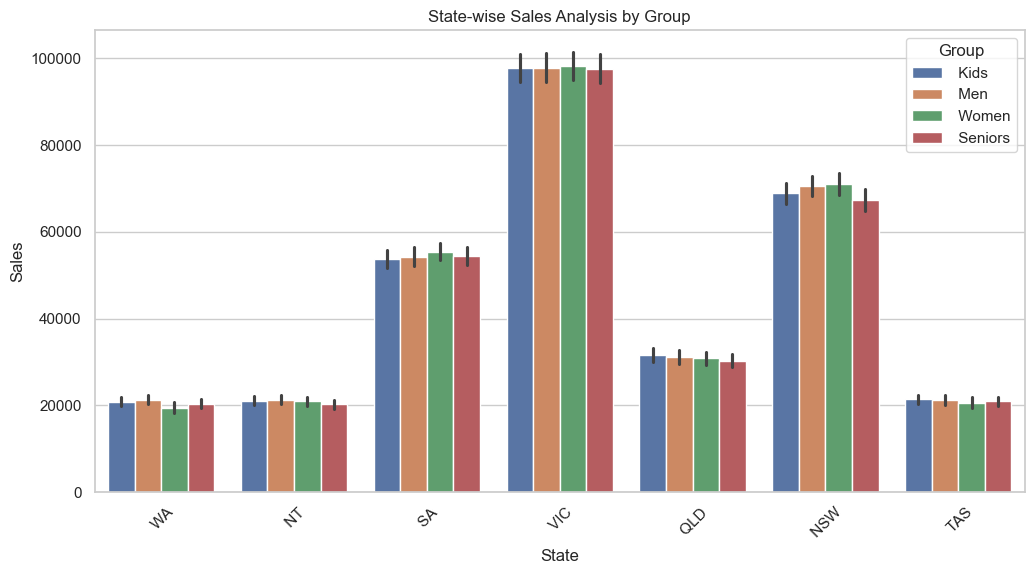

In [25]:
# ================================
# State-wise Sales Analysis
# ================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=sales_df.reset_index(),
    x='State',
    y='Sales',
    hue='Group'
)

plt.title("State-wise Sales Analysis by Group")
plt.xticks(rotation=45)

plt.show()

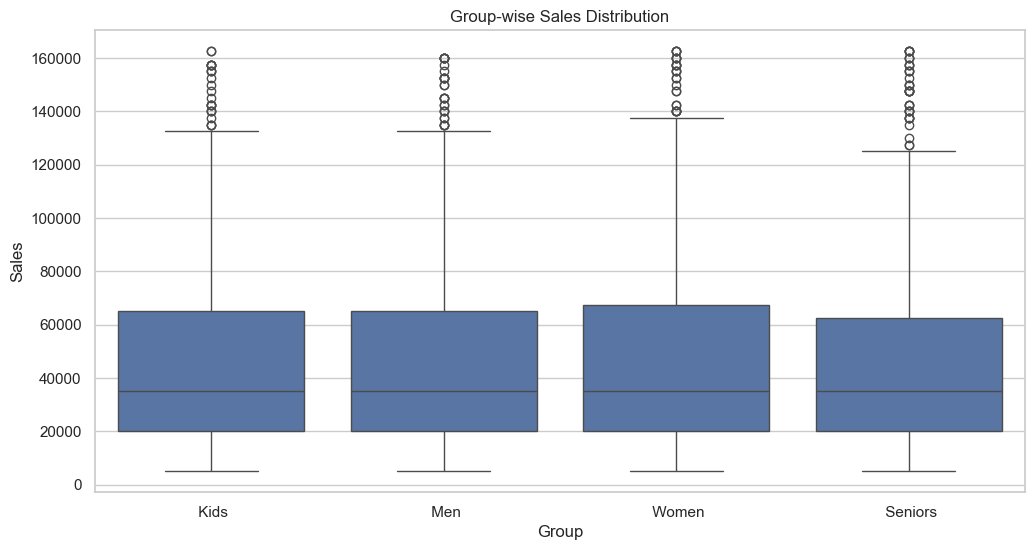

In [26]:
# ================================
# Group-wise Sales Across States
# ================================

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=sales_df.reset_index(),
    x='Group',
    y='Sales'
)

plt.title("Group-wise Sales Distribution")

plt.show()

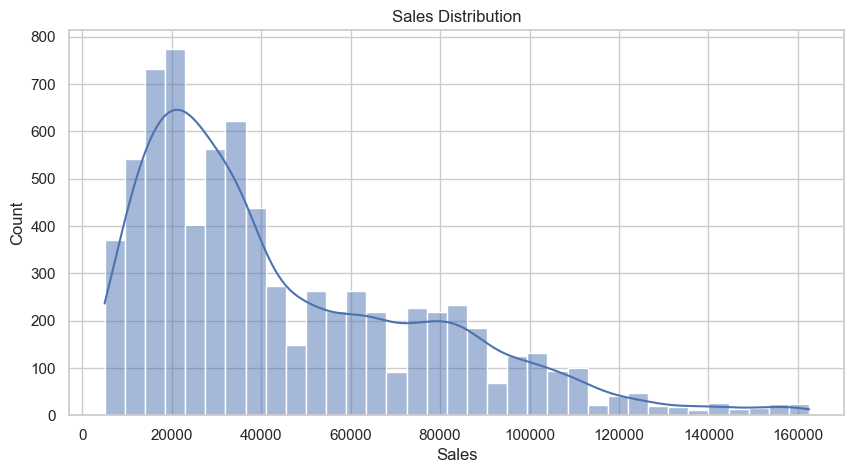

In [27]:
# ================================
# Sales Distribution Plot
# ================================

plt.figure(figsize=(10, 5))

sns.histplot(
    sales_df['Sales'],
    kde=True
)

plt.title("Sales Distribution")

plt.show()

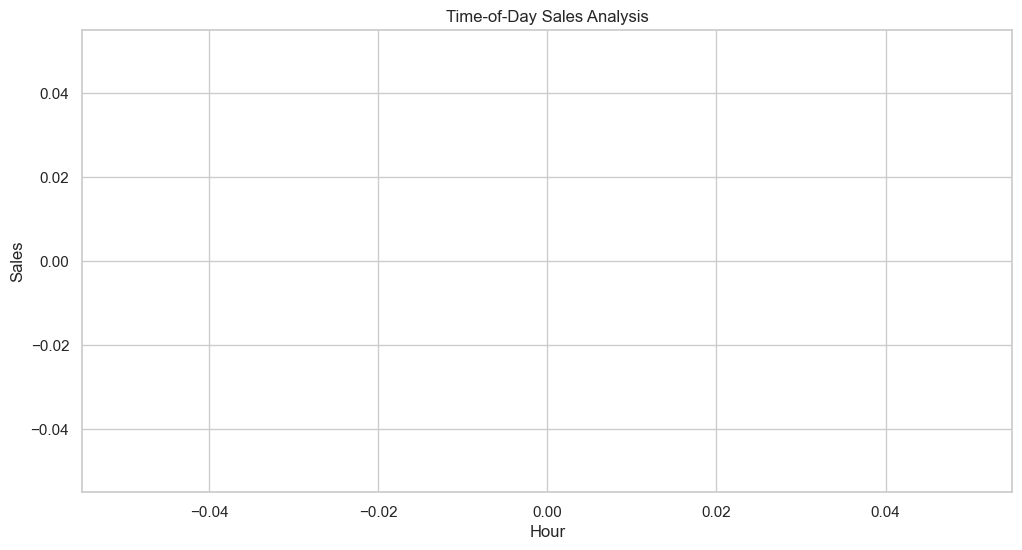

In [35]:
# ================================
# Time-of-Day Sales Analysis
# ================================

# Extract hour from Time column if available

if 'Time' in sales_df.columns:
    
    # Map categorical time-of-day labels to representative hours
    time_mapping = {
        'Morning': 9,
        'Afternoon': 15,
        'Evening': 19
    }

    sales_df['Hour'] = sales_df['Time'].map(time_mapping)

    # If any remaining values can be parsed as actual times, convert them too
    if sales_df['Hour'].isna().any():
        sales_df['Hour'] = sales_df['Hour'].fillna(
            pd.to_datetime(sales_df['Time'], format='%I:%M %p', errors='coerce').dt.hour
        )

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=sales_df.reset_index(),
        x='Hour',
        y='Sales'
    )

    plt.title("Time-of-Day Sales Analysis")

    plt.show()

else:
    print("Time column not found in dataset.")

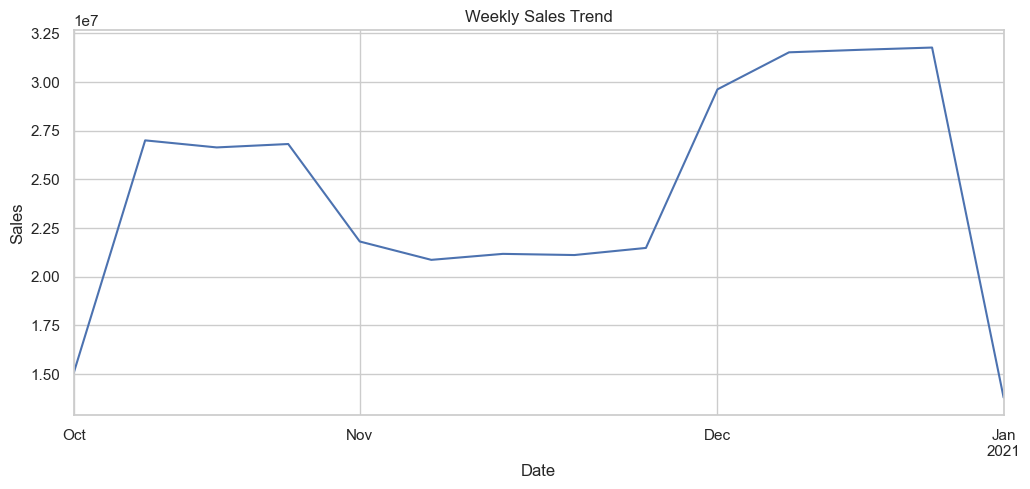

In [33]:
# ================================
# Weekly Sales Trend
# ================================

plt.figure(figsize=(12, 5))

weekly_report.plot()

plt.title("Weekly Sales Trend")
plt.ylabel("Sales")

plt.show()

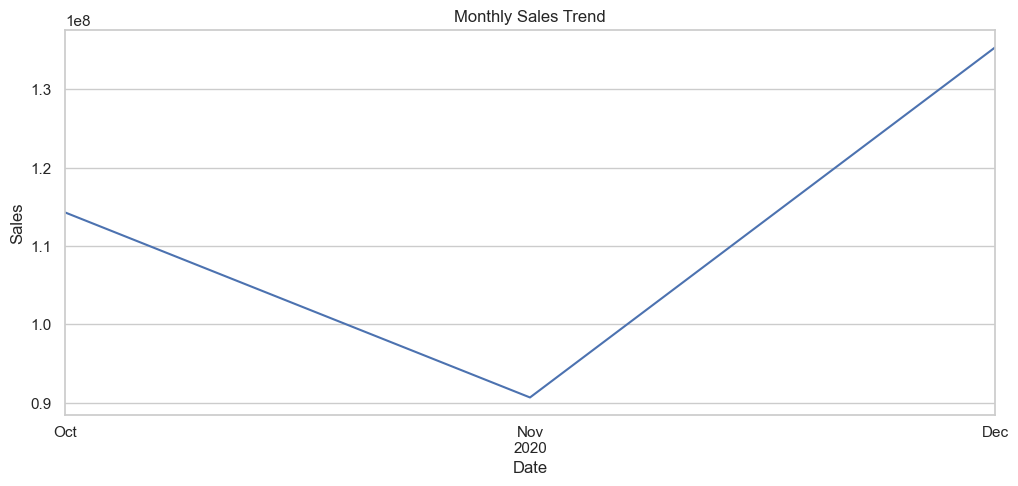

In [34]:
# ================================
# Monthly Sales Trend
# ================================

plt.figure(figsize=(12, 5))

monthly_report.plot()

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")

plt.show()

# 9. Recommendations

## Business Recommendations

### High Revenue States
- Increase inventory and marketing efforts
- Expand premium product offerings
- Strengthen customer loyalty programs

### Low Revenue States
- Launch targeted promotional campaigns
- Introduce localized offers
- Improve regional advertising

### Time-Based Sales Recommendations
- Focus promotions during peak sales hours
- Use personalized offers during off-peak hours
- Optimize staff allocation based on demand

---

## Why Seaborn?
Seaborn is recommended because:
- It provides high-quality statistical visualizations
- Works seamlessly with Pandas
- Simplifies complex plotting
- Produces aesthetically appealing charts


# 10. Conclusion

This notebook successfully demonstrates:
- Data wrangling
- Statistical analysis
- Reporting
- Visualization
- Business recommendations

The analysis helps AAL make data-driven business decisions for future growth and expansion.
